In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [2]:
# read in many of the analysis csv files
df_1 = pd.read_csv("../experiments/scaling_laws/qwen3/gpt_oss_results/breast_cancer_recurrence_multi_model_predictor_answers_20_high_simulatability_analysis.csv")
df_2 = pd.read_csv("../experiments/metric_correlations/breast_cancer_recurrence_counterfactual_dataset_balanced/run_20251126_141718/breast_cancer_recurrence_multi_model_sim_analysis.csv")
df_3 = pd.read_csv("../experiments/metric_correlations/pima_diabetes_counterfactual_dataset_balanced/qwen_results/pima_diabetes_multi_model_predictions_analysis.csv")

df_4 = pd.read_csv("../experiments/dewi/breast_cancer_recurrence_predictor_gemini-2.0-flash_reference_combinations_simulatability_analysis.csv")
df_5 = pd.read_csv("../experiments/dewi/breast_cancer_recurrence_predictor_gemini-2.0-flash-lite_reference_combinations_simulatability_analysis.csv")
df_6 = pd.read_csv("../experiments/dewi/breast_cancer_recurrence_predictor_gemini-2.5-flash-lite_reference_combinations_simulatability_analysis.csv")
df_7 = pd.read_csv("../experiments/dewi/breast_cancer_recurrence_predictor_llama-4-maverick_reference_combinations_simulatability_analysis.csv")
df_8 = pd.read_csv("../experiments/dewi/breast_cancer_recurrence_predictor_mistral-small-3.2-24b-instruct_reference_combinations_simulatability_analysis.csv")

for df in [df_4, df_5, df_6, df_7, df_8]:
    df['normalized_simulatability_gain'] = df.apply(lambda x: (x['simulatability_gain']/(100-x['without_explanation_accuracy'])*100), axis=1)

FileNotFoundError: [Errno 2] No such file or directory: '../experiments/scaling_laws/qwen3/gpt_oss_results/breast_cancer_recurrence_multi_model_predictor_answers_20_high_simulatability_analysis.csv'

In [3]:
# concat
df_total = pd.concat([df_1, df_2, df_3, df_4, df_5, df_6, df_7, df_8])

def corr(a, b):
    return np.corrcoef(a, b)[0, 1]

def corr_with_ci(a, b, n_boot=2000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    a = np.array(a)
    b = np.array(b)
    n = len(a)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(corr(a[idx], b[idx]))
    lower = np.percentile(vals, (100 - ci) / 2)
    upper = np.percentile(vals, 100 - (100 - ci) / 2)
    return corr(a, b), (lower, upper)

def print_corr(label, x, y):
    r, (lo, hi) = corr_with_ci(x, y)
    print(f"{label:<32} {r:>8.4f}    CI [{lo:>7.4f}, {hi:>7.4f}]")

print("="*66)
print("Correlation with 'without explanation accuracy'")
print("="*66)
print_corr("Simulatability", df_total.with_explanation_accuracy, df_total.without_explanation_accuracy)
print_corr("Simulatability Gain", df_total.simulatability_gain, df_total.without_explanation_accuracy)
print_corr("Normalised Simulatability Gain", df_total.normalized_simulatability_gain, df_total.without_explanation_accuracy)

print("\n")
print("="*66)
print("Correlation with 'with explanation accuracy'")
print("="*66)
print_corr("Simulatability", df_total.with_explanation_accuracy, df_total.with_explanation_accuracy)
print_corr("Simulatability Gain", df_total.simulatability_gain, df_total.with_explanation_accuracy)
print_corr("Normalised Simulatability Gain", df_total.normalized_simulatability_gain, df_total.with_explanation_accuracy)


Correlation with 'without explanation accuracy'
Simulatability                     0.7062    CI [ 0.5749,  0.8240]
Simulatability Gain               -0.2510    CI [-0.4597,  0.0100]
Normalised Simulatability Gain     0.1118    CI [-0.0794,  0.3243]


Correlation with 'with explanation accuracy'
Simulatability                     1.0000    CI [ 1.0000,  1.0000]
Simulatability Gain                0.5081    CI [ 0.1939,  0.7439]
Normalised Simulatability Gain     0.7802    CI [ 0.6219,  0.8946]


In [4]:
models = df_3['model']
models

0    Qwen/Qwen3-0.6B
1    Qwen/Qwen3-1.7B
2     Qwen/Qwen3-14B
3     Qwen/Qwen3-32B
4      Qwen/Qwen3-4B
5      Qwen/Qwen3-8B
Name: model, dtype: object

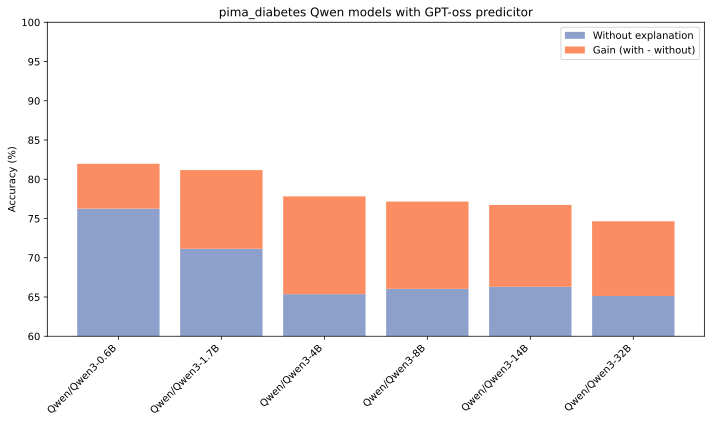

In [7]:
manual_order = [
    'Qwen/Qwen3-0.6B',
    'Qwen/Qwen3-1.7B',
    'Qwen/Qwen3-4B',
    'Qwen/Qwen3-8B',
    'Qwen/Qwen3-14B',
    'Qwen/Qwen3-32B',
]
df_plot = df_3.set_index('model').reindex(manual_order).reset_index()

models = df_plot['model']
without_acc = df_plot['without_explanation_accuracy']
with_acc = df_plot['with_explanation_accuracy']
gain = with_acc - without_acc

plt.figure(figsize=(10, 6))
plt.bar(models, without_acc, label='Without explanation', color='#8da0cb')
plt.bar(models, gain, bottom=without_acc, label='Gain (with - without)', color='#fc8d62')

plt.ylabel('Accuracy (%)')
plt.ylim(60,100)
plt.xticks(rotation=45, ha='right')
plt.title('pima_diabetes Qwen models with GPT-oss predicitor')
plt.legend()
plt.tight_layout()

